Tool calling loop is a core pattern for LLM agents. 
the graph alternates between an LLM node and a tool execution node. 

the goal is to understand. 
- how to design a state machine that loops between nodes.
- how to route based on state. 
- and how to avoid infinite loops. 

In [2]:
!pip install langgraph -q

In [3]:
from typing import TypedDict, Annotated, Literal
import operator
from langgraph.graph import StateGraph, START, END

1. state definition

In [4]:
class State(TypedDict):
    messages: Annotated[list[dict], operator.add]
    tool_calls: list[dict] # pending tool call requests
    iterations: int # track loop count and enforce a limit


2. A mock tool

In [5]:
def get_weather(city: str) -> str:
    """Return a mock weather forecast for a city."""
    return f"The weather in {city} is sunny with a high of 25°C."

for tool execution, we need to know which tool to call and with what arguments. The LLM will produce a tool call like. 

```json
{"name": "get_weather", "arguments": {"city": "Paris"}}
```

the tool node will look up the function by name, call it and add the result to messages. 

3. Simulate LLM node. 

- on the first call, returns a tool call.
- after receiving the tool result, returns the final answer.
- to demonstrate looping, asking for london second time. 


In [6]:
class DummyLLM:
    def __init__(self, plan: list):
        self.plan = plan
        self.step_index = 0
    
    def __call__(self, state: State) -> dict:
        if self.step_index >= len(self.plan):
            return {"messages": [{"role": "assistant", "content": "I don't know."}], "tool_calls": []}
        
        if state["iterations"] >= 5:
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "Stopping due to max iterations."
                    }
                ],
                "tool_calls": []
            }
        
        step = self.plan[self.step_index]
        self.step_index += 1

        if step["type"] == "tool_call":
            return {
                "messages" : [
                    {
                        "role": "assistant",
                        "content": f"calling tool {step['tool']} with {step['args']}",
                    }
                ],
                "tool_calls" : [
                    {"name": step["tool"], "arguments": step["args"]}
                ],
                "iterations": state["iterations"] + 1,
            }
        
        else:
            return {
                "messages": [{"role": "assistant", "content": step["content"]}],
                "tool_calls": [],
                "iterations": state["iterations"] + 1,
            }

4. Tool execution node. 

- checks pending tool calls list. 
- if there are multiple executes them all or just the first. 
- here only first is executed.
- in advanced agent, all might be done in parallel. 

In [7]:
def tool_node(state: State) -> dict:
    print("     tool node       ")
    if not state.get("tool_calls"):
        return {}

    tool_messages = []
    
    for call in state["tool_calls"]:
        name = call["name"]
        args = call["arguments"]

        if name == "get_weather":
            result = get_weather(args["city"])
        else:
                result = f"Error: unknown tool '{name}'"
        tool_messages.append({"role": "tool", "content": result, "name": name})

    return {
        "messages" : tool_messages,
        "tool_calls": [],
    }

5. Routing logic. 

after LLM node we route. 
- if pending tool calls go to tool_node. 
- else got to end.
- max 5 iteration to prevent infinite loops. 

In [8]:
def route_after_llm(state: State) -> Literal["tool_node", END]:
    if state["iterations"] >= 5:
        print("Max iterations reached, stopping.")
        return END
    if state.get("tool_calls"):
        return "tool_node"
    else:
        return END

iteration counter will be incremented in the LLM node each time it runs. So go back to above Dummy LLM node and update the __call__ with iterations: state["iterations"] + 1. 

also check the max iterations before processing the plan.

6. Building the graph.

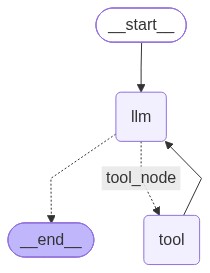

In [9]:
graph = StateGraph(State)

llm = DummyLLM(plan=[
    {"type": "tool_call", "tool": "get_weather", "args": {"city": "Paris"}},
    {"type": "tool_call", "tool": "get_weather", "args": {"city": "London"}},
    {"type": "final_answer", "content": "The weather in Paris is sunny and in London it's cloudy."},
])

graph.add_node("llm", llm)
graph.add_node("tool", tool_node)

graph.add_edge(START, "llm")
graph.add_conditional_edges(
    "llm",
    route_after_llm,
    {
        "tool_node": "tool",
        END: END
    },
)

graph.add_edge("tool", "llm") # loop back

app = graph.compile()
app

7. Run the graph

In [10]:
initial_state = {
    "messages": [],
    "tool_calls": [],
    "iterations": 0,
}

result = app.invoke(initial_state)
print("Final messages:")

for msg in result["messages"]:
    print(f" {msg['role']}: {msg['content']}")

print("Iterations", result["iterations"])

     tool node       
     tool node       
Final messages:
 assistant: calling tool get_weather with {'city': 'Paris'}
 tool: The weather in Paris is sunny with a high of 25°C.
 assistant: calling tool get_weather with {'city': 'London'}
 tool: The weather in London is sunny with a high of 25°C.
 assistant: The weather in Paris is sunny and in London it's cloudy.
Iterations 3


8. Handling multiple tool calls in parallel

- iterating over tool calls executing each and returning the list of tool messages. 



In [11]:
class DummyLLMParallel(DummyLLM):
    def __init__(self, plan: list):
        self.plan = plan
        self.step_index = 0
    
    def __call__(self, state: State) -> dict:
        if state['iterations'] >= 5:
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "Stopping."
                    }
                ],
                "tool_calls": []
            }
        
        if self.step_index >= len(self.plan):
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "I have no more steps."
                    }
                ],
                "tool_calls": [],
            }
        
        step = self.plan[self.step_index]
        self.step_index += 1

        if step["type"] == "tool_call":
            calls = step.get(
                "calls", 
                [{
                    "name": step["name"],
                    "arguments": step["args"]
                }])
            
            return {
                "messages" : [
                    {
                        "role": "assistant",
                        "content": f"calling {len(calls)} tools"
                    }
                ],
                "tool_calls": calls,
                "iterations": state["iterations"] + 1,
            }
        else:
            return {
                "messages" : [
                    {
                        "role": "assistant",
                        "content": step["content"]
                    }
                ],
                "tool_calls": [],
                "iterations": state["iterations"] + 1,
            }

also the tool_node is modified to handle the multiple calls. 

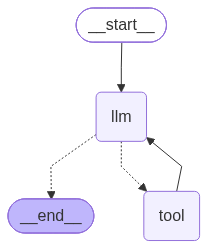

In [12]:
parallel_plan = [
    {
        "type": "tool_call",
        "calls": [
            {"name": "get_weather", "arguments": {"city": "Paris"}},
            {"name": "get_weather", "arguments": {"city": "London"}},
        ],
    },
    {"type": "final_answer", "content": "Both weather results are ready."},
]


llm_parallel = DummyLLMParallel(plan=parallel_plan)

graph_parallel = StateGraph(State)
graph_parallel.add_node("llm", llm_parallel)
graph_parallel.add_node("tool", tool_node)  # the updated tool_node handles multiple calls

graph_parallel.add_edge(START, "llm")
graph_parallel.add_conditional_edges(
    "llm",
    route_after_llm,
    {"tool": "tool", END: END},
)
graph_parallel.add_edge("tool", "llm")  # loop back

app_parallel = graph_parallel.compile()

app_parallel

In [15]:
initial_state = {
    "messages": [],
    "tool_calls": [],
    "iterations": 0,
}

result_parallel = app_parallel.invoke(initial_state)

print("Final messages:")
for msg in result_parallel["messages"]:
    print(f"  {msg['role']}: {msg['content']}")

print("\nIterations:", result_parallel["iterations"])

Final messages:
  assistant: Both weather results are ready.

Iterations: 1
